In [1]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np


def vec_pearson_corrcoef(X: np.array, Y: np.array, k):
    Sx  = X.sum(-1) 
    Sy  = Y.sum(-1)
    Sxx = (X * X).sum(-1)
    Syy = (Y * Y).sum(-1)
    Sxy = (X * Y).sum(-1)

    num = k*Sxy - Sx*Sy
    den = np.sqrt((k*Sxx - Sx*Sx) * (k*Syy - Sy*Sy))
    
    r = np.zeros_like(num, dtype=np.float32)
    np.divide(num, den, out=r, where=den!=0)
    return r



def sphere_mask(r):
    """
    Create a sphere of indices
    Uses mgrid to create a cube and then checks which 
    indices are less than the radius 
    Parameters
    ----------
    r

    Returns
    -------

    """
    z,y,x = np.mgrid[-r:r+1, -r:r+1, -r:r+1]
    return (x*x + y*y + z*z) <= r*r   # Assumes isotropic


def rolling_pearson_corr(A, B, radius):
    W = (2*radius+1,)*3  # window shape 
    sph = sphere_mask(radius)  # sphere mask within window              
    k = int(sph.sum())
    
    # Extract all all cube subsets and then mask with our sphere mask
    A_wind = sliding_window_view(A, W)[..., sph]
    B_wind = sliding_window_view(B, W)[..., sph]

    # Reshape sliding window views so that windows are 1D - more efficient 
    A_flat_wind = A_wind.reshape(-1, k)
    B_flat_wind = B_wind.reshape(-1, k)
    
    rho = vec_pearson_corrcoef(A_flat_wind, B_flat_wind, k)
    out_shape = tuple(d - 2*radius for d in A.shape)
    rho_valid = rho.reshape(out_shape)

    # Embed back into full-sized volume, padding AFTER the correlation
    out = np.full(A.shape, 0, dtype=np.float32)
    out[radius:-radius, radius:-radius, radius:-radius] = rho_valid

    return out


In [2]:



from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_eog=False,
)

In [ ]:
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap

window_size = 3 

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)
for state_1 in ("", "_W", "_S"):
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/eog_mreyemove_rho_maps/thresholded")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{state_1}_correlation_map"
    mreyemove_group_W,_ = mrio.load_second_level_result(contrast=f"mreyemove{state_1}", desc_add="clean-with-fd-clamped-original-sleep")
    eog_group_W,_ = mrio.load_second_level_result(contrast=f"eog{state_1}", desc_add="eog-sleep")    
    correlation_map = rolling_pearson_corr(
            mreyemove_group_W.t_stat.get_fdata(),
            eog_group_W.t_stat.get_fdata(),
            radius=window_size
        )
    positive_corr = correlation_map[correlation_map > 0]
    negative_corr = correlation_map[correlation_map < 0]
    print(f"Comparing {state_1}  for voxel vs EOG")

    
    brain_mask = (np.abs(mreyemove_group_W.t_stat.get_fdata()) > 1e-6) & \
                (np.abs(eog_group_W.t_stat.get_fdata()) > 1e-6)
    brain_corr = correlation_map[brain_mask]
    print(f"Positive > {threshold}: {(brain_corr > threshold).sum() / brain_corr.size:.3f}")
    print(f"Negative < {threshold}: {(brain_corr < -threshold).sum() / brain_corr.size:.3f}")
        
    correlation_img = new_img_like(mreyemove_group_W.t_stat, correlation_map, copy_header=True)
    plot_img_on_surf_with_contour(
        stat_map=correlation_img,
        views=["medial", "lateral"],
        hemispheres=["left", "right"],
        surf_mesh="fsaverage7",
        output_file=output_path,
        cmap=custom_cmap(),
        threshold=0.3,
        vmin=-1,
        vmax=1,
        bg_on_data=True,
        inflate=True,
        title=f"Spotlight Map Correlation for contrast {state_1[1:]}",
    )
    



Comparing   for voxel vs EOG
Positive > 0.3: 0.520
Negative < 0.3: 0.026
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
Comparing _W  for voxel vs EOG
Positive > 0.3: 0.467
Negative < 0.3: 0.045
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
Comparing _S  for voxel vs EOG
Positive > 0.3: 0.558
Negative < 0.3: 0.018
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii


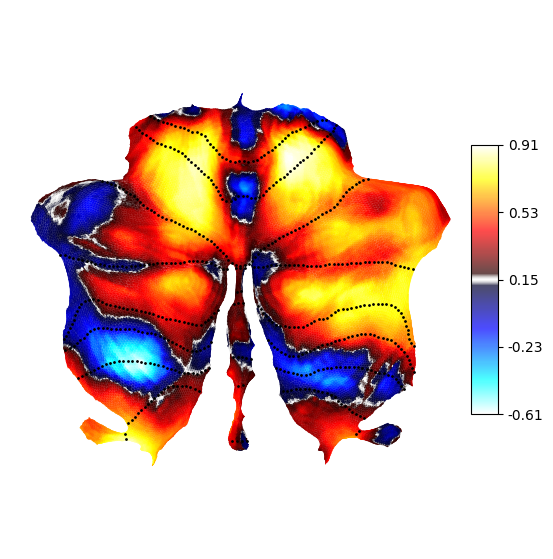

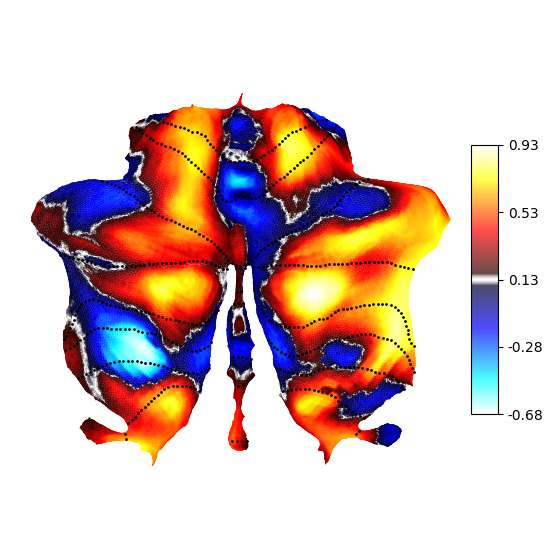

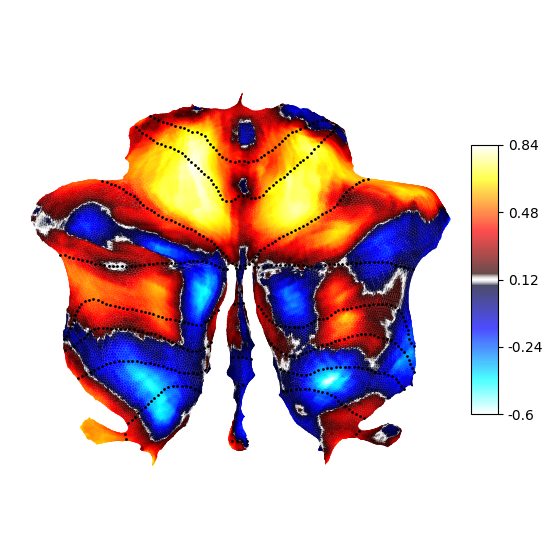

In [4]:
from SUITPy import flatmap
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
import nibabel as nib 

window_size = 3 

threshold = 0.3
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)
for state_1 in ("", "_W", "_S"):
    output_dir = Path("/Users/zach/2025_RA/matthias/final images/group_level/eog_mreyemove_rho_maps/thresholded")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{state_1}_correlation_map"
    mreyemove_group_W,_ = mrio.load_FLAME_result(contrast=f"mreyemove{state_1}", desc_add="clean-with-fd-clamped-original-sleep")
    eog_group_W,_ = mrio.load_FLAME_result(contrast=f"eog{state_1}", desc_add="eog-sleep")    
    correlation_map = rolling_pearson_corr(
            mreyemove_group_W.t_stat.get_fdata(),
            eog_group_W.t_stat.get_fdata(),
            radius=window_size
        )
    positive_corr = correlation_map[correlation_map > 0]
    negative_corr = correlation_map[correlation_map < 0]
    print(f"Comparing {state_1}  for voxel vs EOG")

    
    brain_mask = (np.abs(mreyemove_group_W.t_stat.get_fdata()) > 1e-6) & \
                (np.abs(eog_group_W.t_stat.get_fdata()) > 1e-6)
    brain_corr = correlation_map[brain_mask]
    print(f"Positive > {threshold}: {(brain_corr > threshold).sum() / brain_corr.size:.3f}")
    print(f"Negative < {threshold}: {(brain_corr < -threshold).sum() / brain_corr.size:.3f}")
        
    correlation_img = new_img_like(mreyemove_group_W.t_stat, correlation_map, copy_header=True)
    # plot_img_on_surf_with_contour(
    #     stat_map=correlation_img,
    #     views=["medial", "lateral"],
    #     hemispheres=["left", "right"],
    #     surf_mesh="fsaverage7",
    #     output_file=output_path,
    #     cmap=custom_cmap(),
    #     threshold=0.3,
    #     vmin=-1,
    #     vmax=1,
    #     bg_on_data=True,
    #     inflate=True,
    #     title=f"Spotlight Map Correlation for contrast {state[1:]}",
    # )


    funcdata = flatmap.vol_to_surf(correlation_img,space='FSL')
    
    ax = flatmap.plot(data=funcdata, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib')
    
    ax.figure.savefig(f"{output_path}-SUIT.png", format="png", dpi=300, bbox_inches="tight")

In [ ]:
data_a, _ = mrio.load_FLAME_result(contrast="mreyemove_S", desc_add=desc_add)     
plot_img_on_surf_with_contour(
    stat_map=data_a.t_stat,
    views=["medial", "lateral"],
    hemispheres=["left", "right"],
    surf_mesh="fsaverage5",
    # output_file=output_dir / f"{state}_{state_2}_correlation_map",
    cmap=custom_cmap(),
    # threshold=0.3,
    # vmin=-1,
    # vmax=1,
    bg_on_data=True,
    inflate=True,
    # title=f"Correlation for contrasts {state} vs {state_2}",
)

Comparing S and W
Positive > 0.3: 0.535
Negative < -0.3: 0.050
Mean corr positive = 0.4438192844390869
Mean corr negative = -0.22597523033618927
Voxels below threshold = 0.4154741885331726
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii


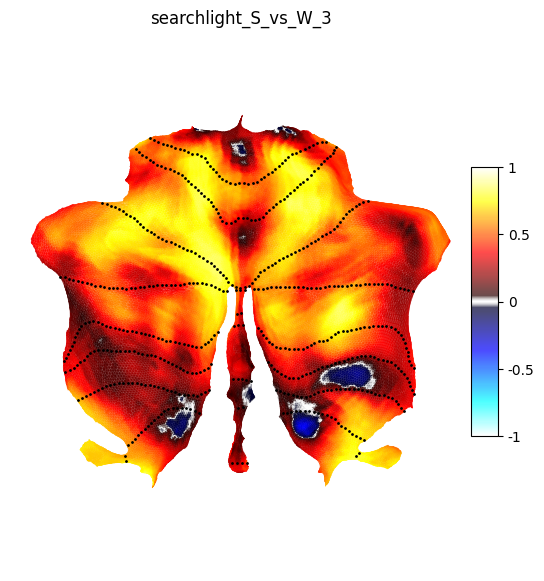

In [23]:
import nibabel as nib 
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap

from itertools import product

window_size = 3
threshold = 0.3
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/') 
output_dir.mkdir(parents=True, exist_ok=True)
brain_mask = nib.load(mrio.second_level_glm_mask_path()).get_fdata().astype(bool)

# desc_add = "clean-with-fd-clamped-original"
# a = ["2","W", "1",]
# b = ["2","W", "1"]
# pairs = [(x, y) for x, y in product(a, b) if x <= y and x != y]

a = ["S","W"]
b = ["S","W"]
desc_add = "clean-with-fd-clamped-original-sleep"
pairs = [(x, y) for x, y in product(a, b) if x <= y and x != y]
for pair in pairs:
    state_1 = pair[0]
    state_2 = pair[1]
    print(f"Comparing {state_1} and {state_2}")
    mreyemove_group_1,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
    mreyemove_group_2,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_2}", desc_add=desc_add)
    correlation_map = rolling_pearson_corr(
            mreyemove_group_1.t_stat.get_fdata(),
            mreyemove_group_2.t_stat.get_fdata(),
            radius=window_size
        )
    
    brain_corr = correlation_map[brain_mask]
    print(f"Positive > 0.3: {(brain_corr > threshold).sum() / brain_corr.size:.3f}")
    print(f"Negative < -0.3: {(brain_corr < -threshold).sum() / brain_corr.size:.3f}")
    
    positive_corr = brain_corr[brain_corr > 0]
    negative_corr = brain_corr[brain_corr < 0]
    correlation_img = new_img_like(mreyemove_group_1.t_stat, correlation_map, copy_header=True)

    # print(f"Positive voxels above threshold {(positive_corr > threshold).sum() / correlation_map.size}")
    print(f"Mean corr positive = {(positive_corr).mean()}")
    # print(f"Negative voxels above threshold {(negative_corr < -threshold).sum() / correlation_map.size}")
    print(f"Mean corr negative = {(negative_corr).mean()}")
    print(f"Voxels below threshold = {(np.abs(brain_corr) < threshold).sum() / brain_corr.size}")
    
    title = f"searchlight_{state_1}_vs_{state_2}_{window_size}"
    output_path = output_dir / f"{title}.png"
    funcdata = flatmap.vol_to_surf(correlation_img,space='FSL')
    
    ax = flatmap.plot(data=funcdata, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
    cscale=[-1.0,1.0])
    ax.set_title(title)
    
    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")




In [ ]:
"""
Positive > 0.3: 0.535
Negative < -0.3: 0.050
Mean corr positive = 0.4438192844390869
Mean corr negative = -0.22597523033618927
Voxels below threshold = 0.4154741885331726
""""

In [14]:

pairs

[('S', 'W')]

In [ ]:



from nilearn import image
from pathlib import Path
from nilearn.image import new_img_like
from mreyemove.plotting.glm import plot_img_on_surf_with_contour, custom_cmap
import nibabel as nib 

window_size = 3 
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/mreyemove_state_rho_maps_sleep'
) 
output_dir.mkdir(parents=True, exist_ok=True)
desc_add = "clean-with-fd-clamped-original-sleep"
task = "movie"
for state_1 in ("W", "S"):

    print(f"Comparing {state_1} and {task}")
    mreyemove_group_1,_ = mrio.load_second_level_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
    mreyemove_group_2 = nib.load(f"/Users/zach/Downloads/Sherlock data/npspmT_unthresholded_{task}.nii")
    
    movie_data = mreyemove_group_2.get_fdata()
    movie_data[np.isnan(movie_data)] = 0
    mreyemove_group_2 = new_img_like(mreyemove_group_2, movie_data)
    movie_resliced = image.resample_to_img(mreyemove_group_2, mreyemove_group_1.t_stat, force_resample=True, copy_header=True)
    
    both_mask = (np.abs(mreyemove_group_1.t_stat.get_fdata()) > 0) & (np.abs(movie_resliced.get_fdata()) > 0)

    my_masked = mreyemove_group_1.t_stat.get_fdata() * both_mask
    movie_masked = movie_resliced.get_fdata() * both_mask
  
    correlation_map = rolling_pearson_corr(
            my_masked,
            movie_masked,
            radius=window_size
        )
    brain_mask = np.abs(correlation_map) > 1e-6
    brain_corr = correlation_map[brain_mask]
    print(f"Positive > 0.3: {(brain_corr > threshold).sum() / brain_corr.size:.3f}")
    print(f"Negative < -0.3: {(brain_corr < -threshold).sum() / brain_corr.size:.3f}")
    
    positive_corr = brain_corr[brain_corr > 0]
    negative_corr = brain_corr[brain_corr < 0]
    
    # print(f"Positive voxels above threshold {(positive_corr > threshold).sum() / correlation_map.size}")
    print(f"Mean corr positive = {(positive_corr).mean()}")
    # print(f"Negative voxels above threshold {(negative_corr < -threshold).sum() / correlation_map.size}")
    print(f"Mean corr negative = {(negative_corr).mean()}")
    print(f"Voxels below threshold = {(np.abs(brain_corr) < threshold).sum() / brain_corr.size}")
    
    correlation_img = new_img_like(mreyemove_group_1.t_stat, correlation_map, copy_header=True)
    plot_img_on_surf_with_contour(
        stat_map=correlation_img,
        views=["medial", "lateral"],
        hemispheres=["left", "right"],
        surf_mesh="fsaverage7",
        output_file=output_dir / f"{state_1}_{task}_correlation_map",
        cmap=custom_cmap(),
        threshold=0.3,
        vmin=-1,
        vmax=1,
        bg_on_data=True,
        inflate=True,
        title=f"Correlation for contrasts {state_1} vs {task}",
    )

